In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [11]:
print("="*50)
print("ШАГ 1 — ЗАГРУЗКА ДАННЫХ И ПРОВЕРКА")
print("="*50)

# 1. Загружаем файл
df = pd.read_csv('dip_hw_covid.csv')

# 2. Показываем информацию
print(f"Размер исходных данных: {df.shape}")
print(f"\nТипы данных:")
print(df.dtypes)
print(f"\nПервые 5 строк:")
print(df.head())

# 3. Проверяем пустые значения
print(f"\nПустые значения по столбцам:")
print(df.isnull().sum())
print(f"Всего пустых значений: {df.isnull().sum().sum()}")

# 4. Очищаем данные
df_clean = df.dropna().drop_duplicates()
print(f"\nРазмер после очистки: {df_clean.shape}")

ШАГ 1 — ЗАГРУЗКА ДАННЫХ И ПРОВЕРКА
Размер исходных данных: (1120, 4)

Типы данных:
date          object
country       object
confirmed    float64
deaths       float64
dtype: object

Первые 5 строк:
                  date country  confirmed  deaths
0  2020-01-22 00:00:00  Russia        0.0     0.0
1  2020-01-22 00:00:00      US        1.0     0.0
2  2020-01-23 00:00:00  Russia        0.0     0.0
3  2020-01-23 00:00:00      US        1.0     0.0
4  2020-01-24 00:00:00  Russia        0.0     0.0

Пустые значения по столбцам:
date         4
country      4
confirmed    4
deaths       4
dtype: int64
Всего пустых значений: 16

Размер после очистки: (1116, 4)


<p>Расчет корреляции</p>

In [12]:
print("\n" + "="*50)
print("ШАГ 2.1 — РАСЧЕТ КОРРЕЛЯЦИИ МЕЖДУ ЗАБОЛЕВАЕМОСТЬЮ И СМЕРТНОСТЬЮ")
print("="*50)

# Корреляция для всех данных
overall_corr = df_clean['confirmed'].corr(df_clean['deaths'])
print(f"1. Общая корреляция (все данные): {overall_corr:.4f}")

# Корреляция по странам отдельно
print("\n2. Корреляция по странам:")
for country in df_clean['country'].unique():
    country_data = df_clean[df_clean['country'] == country]
    corr = country_data['confirmed'].corr(country_data['deaths'])
    print(f"   {country}: {corr:.4f}")
    
# Интерпретация
print("\n3. Интерпретация:")
print("   - Корреляция близка к 1: сильная положительная связь")
print("   - Чем выше заболеваемость, тем выше смертность")
print("   - Значения > 0.99 говорят о почти линейной зависимости")


ШАГ 2.1 — РАСЧЕТ КОРРЕЛЯЦИИ МЕЖДУ ЗАБОЛЕВАЕМОСТЬЮ И СМЕРТНОСТЬЮ
1. Общая корреляция (все данные): 0.9898

2. Корреляция по странам:
   Russia: 0.9899
   US: 0.9913

3. Интерпретация:
   - Корреляция близка к 1: сильная положительная связь
   - Чем выше заболеваемость, тем выше смертность
   - Значения > 0.99 говорят о почти линейной зависимости


<p>Визуализация динамики</p>


ШАГ 2.2 — ВИЗУАЛИЗАЦИЯ ДИНАМИКИ


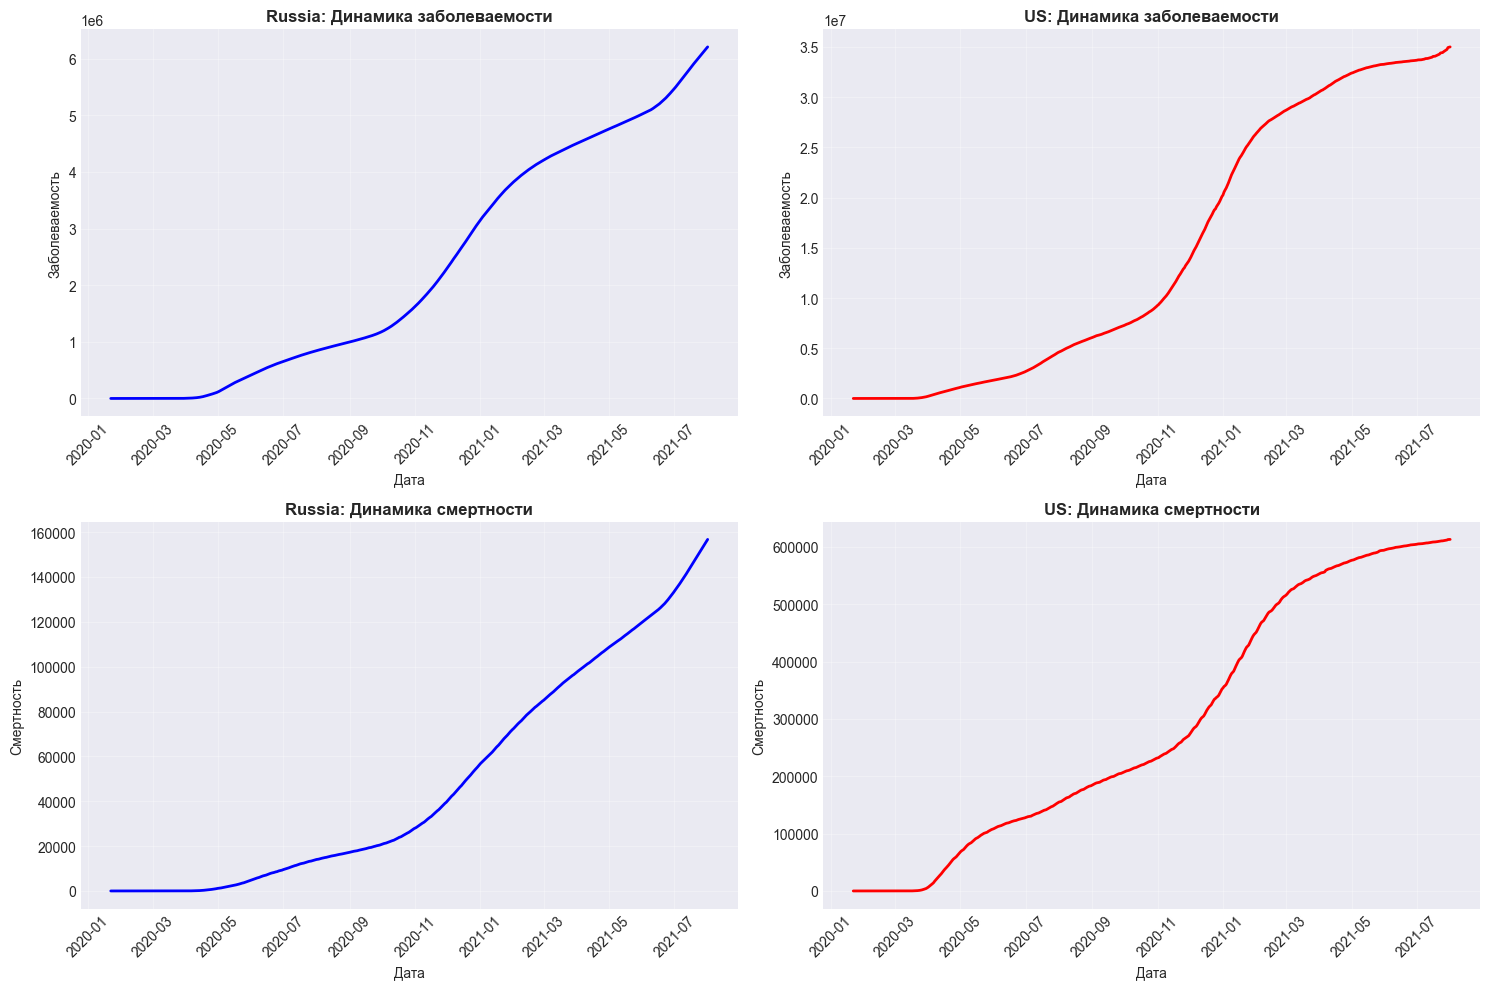

Графики созданы. Наблюдения:
1. Обе страны показывают экспоненциальный рост в начале пандемии
2. Затем рост замедляется и становится более линейным
3. США имеют значительно более высокие абсолютные значения
4. Россия показывает более плавный рост по сравнению с США


In [13]:
print("\n" + "="*50)
print("ШАГ 2.2 — ВИЗУАЛИЗАЦИЯ ДИНАМИКИ")
print("="*50)

# Преобразуем дату в datetime
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Создаем графики
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

countries = ['Russia', 'US']
colors = ['blue', 'red']

for i, country in enumerate(countries):
    country_data = df_clean[df_clean['country'] == country].sort_values('date')
    
    # График заболеваемости
    axes[0, i].plot(country_data['date'], country_data['confirmed'], 
                    color=colors[i], linewidth=2)
    axes[0, i].set_title(f'{country}: Динамика заболеваемости', fontweight='bold')
    axes[0, i].set_xlabel('Дата')
    axes[0, i].set_ylabel('Заболеваемость')
    axes[0, i].tick_params(axis='x', rotation=45)
    axes[0, i].grid(True, alpha=0.3)
    
    # График смертности
    axes[1, i].plot(country_data['date'], country_data['deaths'], 
                    color=colors[i], linewidth=2)
    axes[1, i].set_title(f'{country}: Динамика смертности', fontweight='bold')
    axes[1, i].set_xlabel('Дата')
    axes[1, i].set_ylabel('Смертность')
    axes[1, i].tick_params(axis='x', rotation=45)
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Графики созданы. Наблюдения:")
print("1. Обе страны показывают экспоненциальный рост в начале пандемии")
print("2. Затем рост замедляется и становится более линейным")
print("3. США имеют значительно более высокие абсолютные значения")
print("4. Россия показывает более плавный рост по сравнению с США")

<p>Подготовка данных для модели (Россия)</p>

In [15]:
print("\n" + "="*50)
print("Подготовка данных для модели (Россия)")
print("="*50)

# 1. Формируем выборку по России
russia_data = df_clean[df_clean['country'] == 'Russia'].copy()

print(f"Количество записей по России: {len(russia_data)}")
print(f"\nПервые 5 записей:")
print(russia_data[['date', 'confirmed', 'deaths']].head())
print(f"\nПоследние 5 записей:")
print(russia_data[['date', 'confirmed', 'deaths']].tail())

# Основные статистики
print(f"\nОсновные статистики для России:")
print(f"Максимальное количество заражений: {russia_data['confirmed'].max():,.0f}")
print(f"Максимальное количество смертей: {russia_data['deaths'].max():,.0f}")
print(f"Летальность на конец периода: {(russia_data['deaths'].iloc[-1] / russia_data['confirmed'].iloc[-1]) * 100:.2f}%")


Подготовка данных для модели (Россия)
Количество записей по России: 558

Первые 5 записей:
        date  confirmed  deaths
0 2020-01-22        0.0     0.0
2 2020-01-23        0.0     0.0
4 2020-01-24        0.0     0.0
6 2020-01-25        0.0     0.0
8 2020-01-26        0.0     0.0

Последние 5 записей:
           date  confirmed    deaths
1106 2021-07-28  6116249.0  153620.0
1108 2021-07-29  6138969.0  154404.0
1110 2021-07-30  6161985.0  155180.0
1112 2021-07-31  6185249.0  155952.0
1114 2021-08-01  6207513.0  156726.0

Основные статистики для России:
Максимальное количество заражений: 6,207,513
Максимальное количество смертей: 156,726
Летальность на конец периода: 2.52%


<p>Признак и целевая переменная</p>

In [18]:
print("\n" + "="*50)
print("Выделение признака и целевой переменной")
print("="*50)

# 2. Выделяем признак (X) и целевую переменную (y)
X = russia_data[['confirmed']].values  # Признак: количество заражений (2D массив для sklearn)
y = russia_data['deaths'].values       # Целевая переменная: количество смертей

print(f"Форма X (признак): {X.shape} → {X.shape[0]} строк, {X.shape[1]} столбец")
print(f"Форма y (целевая переменная): {y.shape} → {y.shape[0]} значений")
print(f"\nТип данных X: {type(X)}")
print(f"Тип данных y: {type(y)}")

print(f"\nПервые 10 значений X (confirmed):")
for i in range(10):
    print(f"  Запись {i}: {X[i][0]:,.0f}")

print(f"\nПервые 10 значений y (deaths):")
for i in range(10):
    print(f"  Запись {i}: {y[i]:,.0f}")

print(f"\nСоответствие значений (первые 5 пар):")
for i in range(5):
    print(f"  confirmed = {X[i][0]:,.0f} → deaths = {y[i]:,.0f}")


Выделение признака и целевой переменной
Форма X (признак): (558, 1) → 558 строк, 1 столбец
Форма y (целевая переменная): (558,) → 558 значений

Тип данных X: <class 'numpy.ndarray'>
Тип данных y: <class 'numpy.ndarray'>

Первые 10 значений X (confirmed):
  Запись 0: 0
  Запись 1: 0
  Запись 2: 0
  Запись 3: 0
  Запись 4: 0
  Запись 5: 0
  Запись 6: 0
  Запись 7: 0
  Запись 8: 0
  Запись 9: 2

Первые 10 значений y (deaths):
  Запись 0: 0
  Запись 1: 0
  Запись 2: 0
  Запись 3: 0
  Запись 4: 0
  Запись 5: 0
  Запись 6: 0
  Запись 7: 0
  Запись 8: 0
  Запись 9: 0

Соответствие значений (первые 5 пар):
  confirmed = 0 → deaths = 0
  confirmed = 0 → deaths = 0
  confirmed = 0 → deaths = 0
  confirmed = 0 → deaths = 0
  confirmed = 0 → deaths = 0


Создание модели + обучение

In [20]:
print("\n" + "="*50)
# Создаем и обучаем модель (используем 100% данных для обучения)
model = LinearRegression()


model.fit(X, y)
print("Модель обучена на всех данных (100% данных для обучения)")

# Параметры модели
print(f"\nПАРАМЕТРЫ МОДЕЛИ:")
print(f"Коэффициент (slope): {model.coef_[0]:.8f}")
print(f"Свободный член (intercept): {model.intercept_:.4f}")
print(f"\nУравнение модели:")
print(f"deaths = {model.coef_[0]:.8f} * confirmed + {model.intercept_:.4f}")

# Интерпретация коэффициента
print(f"\nИНТЕРПРЕТАЦИЯ:")
print(f"Коэффициент {model.coef_[0]:.8f} означает:")
print(f"Каждое дополнительное заражение добавляет {model.coef_[0]:.8f} смертей")
print(f"Или: на 1 млн заражений приходится {model.coef_[0] * 1000000:,.0f} смертей")
print(f"Летальность по модели: {model.coef_[0] * 100:.4f}%")

# Сравнение с фактической летальностью
actual_fatality = (russia_data['deaths'].iloc[-1] / russia_data['confirmed'].iloc[-1]) * 100
print(f"\nСРАВНЕНИЕ:")
print(f"Летальность по модели: {model.coef_[0] * 100:.4f}%")
print(f"Фактическая летальность (на конец данных): {actual_fatality:.4f}%")
print(f"Разница: {abs(model.coef_[0] * 100 - actual_fatality):.4f}%")


Модель обучена на всех данных (100% данных для обучения)

ПАРАМЕТРЫ МОДЕЛИ:
Коэффициент (slope): 0.02352537
Свободный член (intercept): -5713.8279

Уравнение модели:
deaths = 0.02352537 * confirmed + -5713.8279

ИНТЕРПРЕТАЦИЯ:
Коэффициент 0.02352537 означает:
Каждое дополнительное заражение добавляет 0.02352537 смертей
Или: на 1 млн заражений приходится 23,525 смертей
Летальность по модели: 2.3525%

СРАВНЕНИЕ:
Летальность по модели: 2.3525%
Фактическая летальность (на конец данных): 2.5248%
Разница: 0.1722%


Прогноз для 25млн

In [21]:
print("="*50)

# 5. Рассчитываем прогноз для 25 000 000 случаев
new_confirmed = np.array([[25000000]])  # 25 миллионов заражений
predicted_deaths = model.predict(new_confirmed)

print(f"Входные данные для прогноза:")
print(f"  Количество заражений: {new_confirmed[0][0]:,.0f}")
print(f"\nПрогнозируемое количество смертей: {predicted_deaths[0]:,.0f}")
print(f"Прогнозируемая летальность: {(predicted_deaths[0] / 25000000) * 100:.4f}%")

# Сравнение с текущими данными
print(f"\nСРАВНЕНИЕ С ТЕКУЩИМИ ДАННЫМИ:")
print(f"Максимальное зарегистрированное количество заражений: {X.max():,.0f}")
print(f"Прогнозируемое увеличение: в {(25000000 / X.max()):.1f} раз")
print(f"\nТекущее количество смертей: {y.max():,.0f}")
print(f"Прогнозируемое количество смертей: {predicted_deaths[0]:,.0f}")
print(f"Увеличение смертности: в {(predicted_deaths[0] / y.max()):.1f} раз")

# Проверка с использованием уравнения модели
calculated_deaths = model.coef_[0] * 25000000 + model.intercept_
print(f"\nПРОВЕРКА ЧЕРЕЗ УРАВНЕНИЕ:")
print(f"deaths = {model.coef_[0]:.8f} * 25,000,000 + ({model.intercept_:.4f})")
print(f"deaths = {model.coef_[0] * 25000000:,.2f} + ({model.intercept_:,.2f})")
print(f"deaths = {calculated_deaths:,.0f}")

Входные данные для прогноза:
  Количество заражений: 25,000,000

Прогнозируемое количество смертей: 582,420
Прогнозируемая летальность: 2.3297%

СРАВНЕНИЕ С ТЕКУЩИМИ ДАННЫМИ:
Максимальное зарегистрированное количество заражений: 6,207,513
Прогнозируемое увеличение: в 4.0 раз

Текущее количество смертей: 156,726
Прогнозируемое количество смертей: 582,420
Увеличение смертности: в 3.7 раз

ПРОВЕРКА ЧЕРЕЗ УРАВНЕНИЕ:
deaths = 0.02352537 * 25,000,000 + (-5713.8279)
deaths = 588,134.21 + (-5,713.83)
deaths = 582,420


Визуализация модели


ШАГ 3.5 — ВИЗУАЛИЗАЦИЯ МОДЕЛИ И ПРОГНОЗА


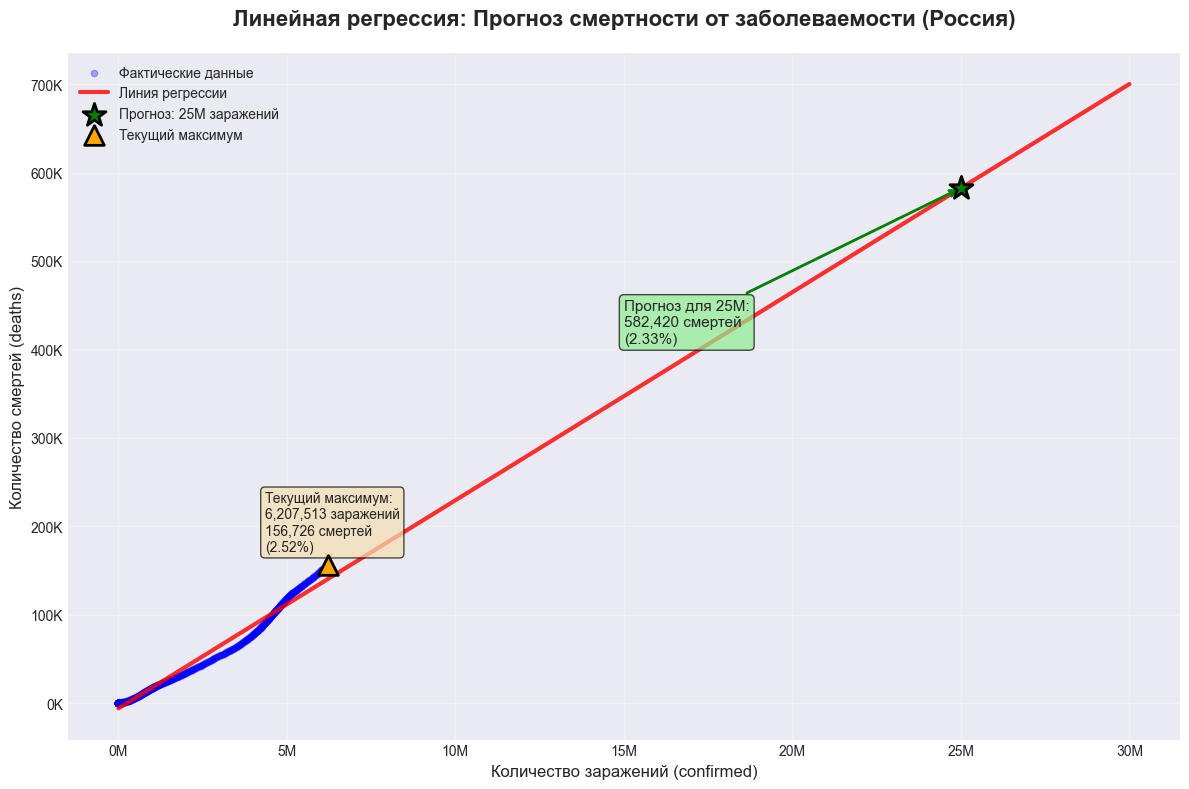

График создан. Основные элементы:
1. Синие точки — фактические данные
2. Красная линия — линия линейной регрессии
3. Зеленая звезда — прогноз для 25 миллионов заражений
4. Оранжевый треугольник — текущие максимальные значения

Прогноз показывает: при 25 млн заражений ожидается 582,420 смертей


In [22]:
print("\n" + "="*50)
print("ШАГ 3.5 — ВИЗУАЛИЗАЦИЯ МОДЕЛИ И ПРОГНОЗА")
print("="*50)

plt.figure(figsize=(12, 8))

# 1. Фактические данные (синие точки)
plt.scatter(X, y, alpha=0.3, label='Фактические данные', color='blue', s=20)

# 2. Линия регрессии (красная линия)
# Создаем диапазон значений для линии от 0 до 30 миллионов
x_range = np.linspace(0, 30000000, 300).reshape(-1, 1)
y_pred_line = model.predict(x_range)
plt.plot(x_range, y_pred_line, color='red', linewidth=3, 
         label='Линия регрессии', alpha=0.8)

# 3. Прогноз для 25 миллионов (большая зеленая звезда)
plt.scatter(25000000, predicted_deaths, color='green', s=300, 
           marker='*', edgecolor='black', linewidth=2, 
           zorder=5, label=f'Прогноз: 25M заражений')

# 4. Текущие максимальные значения (оранжевый треугольник)
plt.scatter(X.max(), y.max(), color='orange', s=200, 
           marker='^', edgecolor='black', linewidth=2,
           zorder=5, label='Текущий максимум')

# Настройки графика
plt.title('Линейная регрессия: Прогноз смертности от заболеваемости (Россия)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Количество заражений (confirmed)', fontsize=12)
plt.ylabel('Количество смертей (deaths)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)

# Добавляем аннотации
plt.annotate(f'Прогноз для 25M:\n{predicted_deaths[0]:,.0f} смертей\n({(predicted_deaths[0]/25000000)*100:.2f}%)',
             xy=(25000000, predicted_deaths[0]),
             xytext=(15000000, predicted_deaths[0]*0.7),
             arrowprops=dict(arrowstyle='->', color='green', linewidth=2),
             fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

plt.annotate(f'Текущий максимум:\n{X.max():,.0f} заражений\n{y.max():,.0f} смертей\n({(y.max()/X.max())*100:.2f}%)',
             xy=(X.max(), y.max()),
             xytext=(X.max()*0.7, y.max()*1.1),
             arrowprops=dict(arrowstyle='->', color='orange', linewidth=1.5),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.7))

# Форматирование осей
plt.gca().get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000000:.0f}M'))
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y/1000:.0f}K'))

plt.tight_layout()
plt.show()

print("График создан. Основные элементы:")
print("1. Синие точки — фактические данные")
print("2. Красная линия — линия линейной регрессии")
print("3. Зеленая звезда — прогноз для 25 миллионов заражений")
print("4. Оранжевый треугольник — текущие максимальные значения")
print(f"\nПрогноз показывает: при 25 млн заражений ожидается {predicted_deaths[0]:,.0f} смертей")

Оценка качества модели

In [26]:
print("\n" + "="*50)
print("Оценка качества модели")
print("="*50)

# Оценка качества модели на всех данных (использовали 100% для обучения)
y_pred_all = model.predict(X)

# Рассчитываем метрики
r2 = r2_score(y, y_pred_all)
mae = mean_absolute_error(y, y_pred_all)
mse = mean_squared_error(y, y_pred_all)
rmse = np.sqrt(mse)

print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ:")
print(f"1. Коэффициент детерминации (R²): {r2:.6f}")
print(f"2. Средняя абсолютная ошибка (MAE): {mae:,.2f}")
print(f"3. Среднеквадратичная ошибка (MSE): {mse:,.2f}")
print(f"4. Корень из среднеквадратичной ошибки (RMSE): {rmse:,.2f}")

# Процентные ошибки
print(f"\nОТНОСИТЕЛЬНЫЕ ОШИБКИ:")
print(f"MAE в % от среднего значения смертей: {(mae / y.mean()) * 100:.2f}%")
print(f"RMSE в % от среднего значения смертей: {(rmse / y.mean()) * 100:.2f}%")
print(f"MAE в % от максимального значения смертей: {(mae / y.max()) * 100:.2f}%")

# Анализ остатков
residuals = y - y_pred_all
print(f"\nАНАЛИЗ ОСТАТКОВ (РАЗНИЦА ФАКТ - ПРОГНОЗ):")
print(f"Среднее остатков: {residuals.mean():,.2f}")
print(f"Стандартное отклонение остатков: {residuals.std():,.2f}")
print(f"Минимальный остаток: {residuals.min():,.2f}")
print(f"Максимальный остаток: {residuals.max():,.2f}")

# Получаем даты для последних 5 наблюдений
dates = russia_data['date'].tail(5).values
X_last = X[-5:]
y_last = y[-5:]
y_pred_last = y_pred_all[-5:]

for i in range(5):
    date_str = pd.to_datetime(str(dates[i])).strftime('%Y-%m-%d')
    error = abs(y_last[i] - y_pred_last[i])
    error_pct = (error / y_last[i]) * 100 if y_last[i] > 0 else 0
    
    print(f"{date_str:<12} {X_last[i][0]:>12,.0f} {y_last[i]:>14,.0f} "
          f"{y_pred_last[i]:>12,.0f} {error:>12,.0f} {error_pct:>9.1f}%")

print("\n интерпритация метрик:")
print(f"1. R² = {r2:.4f} → модель объясняет {r2*100:.1f}% дисперсии данных")
print(f"2. MAE = {mae:,.0f} → в среднем ошибка составляет ±{mae:,.0f} смертей")
print(f"3. Ошибка в %: в среднем ±{(mae / y.mean()) * 100:.1f}% от среднего значения")


Оценка качества модели
МЕТРИКИ КАЧЕСТВА МОДЕЛИ:
1. Коэффициент детерминации (R²): 0.979921
2. Средняя абсолютная ошибка (MAE): 5,316.12
3. Среднеквадратичная ошибка (MSE): 45,756,347.06
4. Корень из среднеквадратичной ошибки (RMSE): 6,764.34

ОТНОСИТЕЛЬНЫЕ ОШИБКИ:
MAE в % от среднего значения смертей: 10.98%
RMSE в % от среднего значения смертей: 13.97%
MAE в % от максимального значения смертей: 3.39%

АНАЛИЗ ОСТАТКОВ (РАЗНИЦА ФАКТ - ПРОГНОЗ):
Среднее остатков: 0.00
Стандартное отклонение остатков: 6,764.34
Минимальный остаток: -12,810.17
Максимальный остаток: 16,405.80
2021-07-28      6,116,249        153,620      138,173       15,447      10.1%
2021-07-29      6,138,969        154,404      138,708       15,696      10.2%
2021-07-30      6,161,985        155,180      139,249       15,931      10.3%
2021-07-31      6,185,249        155,952      139,796       16,156      10.4%
2021-08-01      6,207,513        156,726      140,320       16,406      10.5%

 интерпритация метрик:
1. R² = 

In [28]:
print("1. основной прогноз:")
print(f"   При достижении 25 миллионов заражений в России:")
print(f"   - Прогнозируемое количество смертей: {predicted_deaths[0]:,.0f}")
print(f"   - Прогнозируемая летальность: {(predicted_deaths[0] / 25000000) * 100:.4f}%")

print("\n2. сравнение:")
print(f"   Текущая летальность (на {russia_data['date'].iloc[-1].date()}): "
      f"{(y.max() / X.max()) * 100:.4f}%")
print(f"   Прогнозируемая летальность: {(predicted_deaths[0] / 25000000) * 100:.4f}%")
print(f"   Изменение летальности: "
      f"{((predicted_deaths[0] / 25000000) - (y.max() / X.max())) * 100:+.4f}%")

print("\n3. качество модели:")
print(f"   - R² = {r2:.4f} → очень высокое качество, модель объясняет {r2*100:.1f}% дисперсии")
print(f"   - Средняя ошибка: ±{mae:,.0f} смертей (±{(mae / y.mean()) * 100:.1f}%)")
print(f"   - Для прогноза 582,420 смертей возможная ошибка: "
      f"±{mae:,.0f} (±{(mae / predicted_deaths[0]) * 100:.1f}%)")

print("\n4. Ограничение модели:")
print("   a) Модель линейная → предполагает постоянную летальность")
print("   b) Не учитывает:")
print("      - Изменение эффективности лечения со временем")
print("      - Появление новых штаммов вируса")
print("      - Вакцинацию и её влияние на летальность")
print("      - Изменения в методах диагностики и отчётности")
print("   c) Прогноз экстраполяционный (выходит за пределы обучающих данных)")
print("   d) В начале данных много нулей → может влиять на коэффициент")

print("\n5. Возможная рекомендация:")
print("   a) Прогноз следует использовать как ориентировочный")
print("   b) Рекомендуется регулярно обновлять модель с новыми данными")
print("   c) Учитывать, что летальность может снижаться из-за:")
print("      - Улучшения методов лечения")
print("      - Вакцинации населения")
print("      - Накопленного иммунитета")
print("   d) Для точных прогнозов использовать более сложные модели")

1. основной прогноз:
   При достижении 25 миллионов заражений в России:
   - Прогнозируемое количество смертей: 582,420
   - Прогнозируемая летальность: 2.3297%

2. сравнение:
   Текущая летальность (на 2021-08-01): 2.5248%
   Прогнозируемая летальность: 2.3297%
   Изменение летальности: -0.1951%

3. качество модели:
   - R² = 0.9799 → очень высокое качество, модель объясняет 98.0% дисперсии
   - Средняя ошибка: ±5,316 смертей (±11.0%)
   - Для прогноза 582,420 смертей возможная ошибка: ±5,316 (±0.9%)

4. Ограничение модели:
   a) Модель линейная → предполагает постоянную летальность
   b) Не учитывает:
      - Изменение эффективности лечения со временем
      - Появление новых штаммов вируса
      - Вакцинацию и её влияние на летальность
      - Изменения в методах диагностики и отчётности
   c) Прогноз экстраполяционный (выходит за пределы обучающих данных)
   d) В начале данных много нулей → может влиять на коэффициент

5. Возможная рекомендация:
   a) Прогноз следует использовать к